## DES collection import

Author: Melissa D, Konstantin M

Last run: 2026.04.27

https://github.com/astronomy-commons/data.lsdb.io/issues/99
https://github.com/astronomy-commons/lsdb/issues/1340

In [1]:
# %pip install -U hats-import

In [2]:
import hats
import hats_import
import numpy as np
from dask.distributed import Client
from hats_import import CollectionArguments, pipeline_with_client, pipeline, VerificationArguments
from pathlib import Path
from hats_import.catalog.file_readers import CsvReader
from astropy.io import ascii
import lsdb

hats_import.__version__

/astro/users/kmalanch/.virtualenvs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.9.0'

In [3]:
## input paths:
raw_dir = Path("/astro/store/epyc3/data3/hats/raw/des/des_dr2/")
file_list = list(raw_dir.glob("DES*"))
print("found", len(file_list), "files for import")

# ## Index division hints
# global_min = 4295806720
# global_max = 6917528997577384320
# num_row_groups = 3933

# increment = int((global_max - global_min) / num_row_groups)

# divisions = np.append(np.arange(start=global_min, stop=global_max, step=increment), global_max)
# divisions = divisions.tolist()

# ## Create a schema file, using the contents from the VOTable.

# empty_astropy_table = ascii.read(file_list[0], format="ecsv", data_end=1)
# empty_astropy_table.write("gaia_schema.parquet", overwrite=True)

found 10169 files for import


In [4]:
args = (
    CollectionArguments(
        completion_email_address="delucchi@andrew.cmu.edu",
        output_artifact_name="des_dr2",
        output_path="/astro/store/epyc3/data3/hats/catalogs/v09",
        progress_bar=True,
        simple_progress_bar=True,
    )
    .catalog(
        output_artifact_name="des_dr2",
        input_file_list=file_list,
        file_reader="fits",
        ra_column="RA",
        dec_column="DEC",
        sort_columns="COADD_OBJECT_ID",
        highest_healpix_order=7,
        skymap_alt_orders=[2, 4, 6],
        pixel_threshold=1_000_000,
        row_group_kwargs={"num_rows": 200_000},
    )
    .add_margin(margin_threshold=10.0, is_default=True)
#     .add_margin(margin_threshold=300.0, output_artifact_name="gaia_300arcs")
#     .add_index(
#         indexing_column="source_id",
#         output_artifact_name="gaia_source_id_index",
#         include_healpix_29=False,
#         include_order_pixel=True,
#         compute_partition_size=2_000_000_000,
#         division_hints=divisions,
#         drop_duplicates=False,
#     )
)

In [5]:
with Client(
    local_directory="/astro/store/epyc3/data3/hats/tmp/",
    n_workers=20,
    threads_per_worker=1,
) as client:
    pipeline_with_client(args, client)

Margin: Finishing :  25%|██▌       | 1/4 [00:05<00:15,  5.09s/it]/astro/users/kmalanch/.virtualenvs/default/lib/python3.12/site-packages/hats/catalog/partition_info.py:113: UserWarning: Computing partitions from catalog parquet files. This may be slow.
  warnings.warn("Computing partitions from catalog parquet files. This may be slow.")
Collection: Finishing : 100%|██████████| 2/2 [00:00<00:00,  9.14it/s]


In [6]:
catalog = lsdb.open_catalog("/astro/store/epyc3/data3/hats/catalogs/v09/des_dr2")
len(catalog), len(catalog.margin)

(691483608, 10616007)

(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - des_dr2'}>)

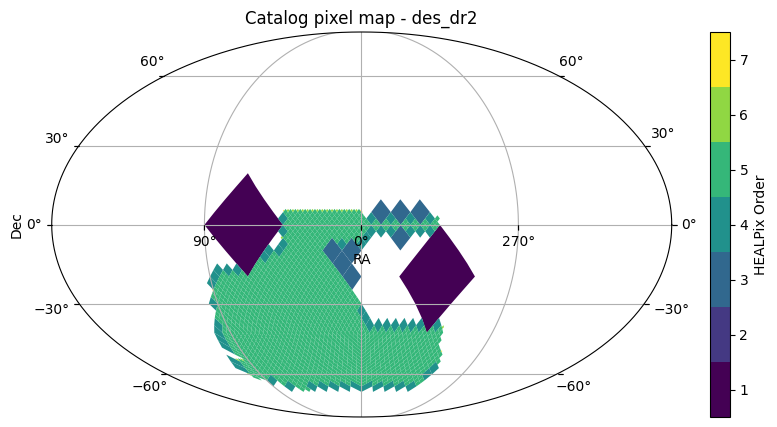

In [7]:
catalog.plot_pixels()

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of des_dr2'}>)

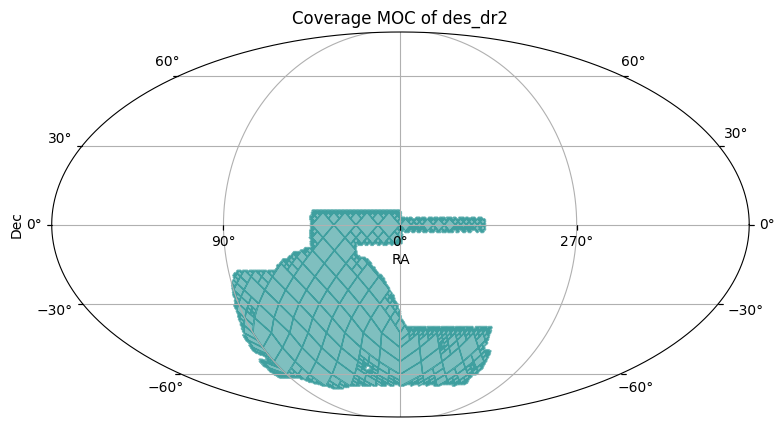

In [8]:
catalog.plot_coverage()

In [9]:
args = VerificationArguments(
    input_catalog_path="/astro/store/epyc3/data3/hats/catalogs/v09/des_dr2/des_dr2",
    output_path="./verification/des_dr2",
)
pipeline(args)

Loading dataset and schema.

Starting: Test hats.io.validation.is_valid_catalog.
Validating catalog at path /astro/store/epyc3/data3/hats/catalogs/v09/des_dr2/des_dr2 ... 
Found 1582 partitions.
Approximate coverage is 19.18 % of the sky.
Result: PASSED

Starting: Test that files in _metadata match the data files on disk.
Result: PASSED

Starting: Test that number of rows are equal.
	file footers vs catalog properties
	file footers vs _metadata
Result: PASSED

Starting: Test that schemas are equal, excluding metadata.
	_common_metadata vs truth
	_metadata vs truth
	file footers vs truth
Result: PASSED

Verifier results written to verification/des_dr2/verifier_results.csv
Elapsed time (seconds): 6.06


We need to expand the verification pipeline to allow passing a catalog collection, and verify that all of the necessary elements of the catalog collection are present. 

This is being tracked in issue: https://github.com/astronomy-commons/hats-import/issues/566

Here, we instead spot-check that the collection looks "about right".

In [10]:
!ls /astro/store/epyc3/data3/hats/catalogs/v09/des_dr2/

collection.properties  des_dr2	des_dr2_10arcs


/astro/users/kmalanch/.local/share/uv/python/cpython-3.12.9-linux-x86_64-gnu/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=812728) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


In [11]:
!cat /astro/store/epyc3/data3/hats/catalogs/v09/des_dr2/collection.properties

#HATS Collection
obs_collection=des_dr2
hats_primary_table_url=des_dr2
all_margins=des_dr2_10arcs
default_margin=des_dr2_10arcs
hats_builder=hats-import v0.9.0, hats v0.9.0
hats_creation_date=2026-04-28T00:28UTC
hats_estsize=708972450
hats_release_date=2025-08-22
hats_version=v1.0
